# Computer Exercise 15.2 — Problem 2

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.) — 확장 사례연구
> **단원**: 15.2 Contextual Bandits — *Linear Thompson Sampling*
> **풀이 일자**: Day 69
> **언어**: Python 3 (NumPy / Matplotlib)


## 1. 문제 (원문)

> **2.** For the same linear contextual bandit model as Problem 1, implement **Linear Thompson Sampling**
> (LinTS). At each round, for each arm $k$ sample $\tilde\theta_k \sim \mathcal{N}(\hat\theta_k,\; v^2 A_k^{-1})$
> and select $A_t = \arg\max_k \tilde\theta_k^\top x_t$. Vary the posterior-scale hyperparameter
> $v \in \{0.1,\,0.5,\,1.0,\,2.0\}$ and compare cumulative regret against the best LinUCB from Problem 1.

### 한국어 풀이용 정리
LinUCB 가 결정론적 상한을 쓰는 대신, LinTS 는 각 팔의 파라미터 사후분포 $\mathcal N(\hat\theta_k, v^2 A_k^{-1})$
로부터 표본 $\tilde\theta_k$를 뽑고 그 표본에 대한 탐욕적 선택을 한다. **표본 자체가 무작위 탐색을 부여**하므로
별도의 $\alpha$가 필요 없다. $v$가 크면 사후분포를 넓게 잡아 탐색이 많아지고, 작으면 좁게 잡아 활용 위주가 된다.


## 2. 수학적 배경

### 2.1 켤레 사후분포
잡음이 $\eta_t \sim \mathcal N(0,\sigma^2)$이고 사전이 $\theta_k \sim \mathcal N(0, \lambda^{-1} I)$이면,
지금까지의 관측조건부 사후분포는

$$
\theta_k \mid \mathcal D_t \;\sim\; \mathcal N\bigl(\hat\theta_k,\; \sigma^2 A_k^{-1}\bigr),
\qquad A_k = \lambda I + \sum_{s\in\mathcal T_k(t)} x_s x_s^\top.
$$

실무에서는 사후 스케일을 하이퍼파라미터 $v$로 재조정해

$$
\tilde\theta_k \;\sim\; \mathcal N(\hat\theta_k, v^2 A_k^{-1})
$$

로 sampling 한 뒤 $A_t = \arg\max_k \tilde\theta_k^\top x_t$.

### 2.2 왜 표본이 탐색을 부여하는가
LinUCB 가 $\alpha\sqrt{x^\top A_k^{-1}x}$를 **더해** 낙관적 상한을 만든다면, LinTS 는
$\tilde\theta_k^\top x = \hat\theta_k^\top x + v\,\xi\sqrt{x^\top A_k^{-1} x}$
($\xi \sim \mathcal N(0,1)$)로 **가우시안 노이즈**를 얹는다. 두 방식 모두 스케일 $\sqrt{x^\top A_k^{-1}x}$가
불확실성을 잰다는 점이 같으나, LinTS 는 절반의 확률로 **음의 편차**도 사용하므로 활용/탐색이 **랜덤하게 섞인다**.

### 2.3 리그렛
Agrawal & Goyal (2013) 은 LinTS 가 $R_T = \tilde O(d^{3/2}\sqrt T)$의 리그렛을 만족함을 보였다.
LinUCB 의 $\tilde O(d\sqrt T)$ 보다 $d$차원 스케일이 약간 나쁘지만, 실무 상수는 종종 LinTS 가 유리하다.


## 3. 풀이 흐름

1. **같은 인스턴스**: 문제 1과 동일한 $\theta_k^\star$ 생성기, 같은 시드 재사용으로 정책 간 공정 비교.
2. **LinTS 구현**: 라운드마다 각 팔에서 $\tilde\theta_k = \hat\theta_k + v\,\mathrm{chol}(A_k^{-1})\,\xi_k$ sampling. Cholesky 는 $A_k^{-1}$이 대칭 양정치임을 이용.
3. **$v$ 스캔**: $v \in \{0.1,\,0.5,\,1.0,\,2.0\}$. 각각 $M=60$ 회 Monte-Carlo, $T=1500$.
4. **LinUCB 비교**: 문제 1의 sweet spot $\alpha=1.0$ 을 재실행해 같은 그림에 겹쳐 그림.
5. **결과 표**: 각 정책의 최종 $R_T$ 평균/표준편차, 최적팔 선택 비율.
6. **결과 해석**: $v$가 너무 작으면 고착, 너무 크면 상수 기울기; LinTS 의 분산은 UCB보다 크나 상수는 작다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

K, d, sigma, lam = 5, 6, 0.1, 1.0
T, M = 800, 20

def make_instance(seed):
    rng = np.random.default_rng(seed)
    theta = rng.standard_normal((K, d))
    theta /= np.linalg.norm(theta, axis=1, keepdims=True)
    return theta, rng

def context(rng):
    x = rng.standard_normal(d)
    return x / np.linalg.norm(x)

def lints_run(v, seed):
    theta_star, rng = make_instance(seed)
    A = np.stack([lam * np.eye(d) for _ in range(K)])
    b = np.zeros((K, d))
    regret = np.zeros(T)
    correct = 0
    for t in range(T):
        x = context(rng)
        mu_star_arm = int(np.argmax(theta_star @ x))
        mu_star = theta_star[mu_star_arm] @ x
        vals = np.empty(K)
        for k in range(K):
            Ainv = np.linalg.inv(A[k])
            th_hat = Ainv @ b[k]
            L = np.linalg.cholesky(Ainv + 1e-10 * np.eye(d))
            xi = rng.standard_normal(d)
            th_tilde = th_hat + v * (L @ xi)
            vals[k] = th_tilde @ x
        a = int(np.argmax(vals))
        r = theta_star[a] @ x + sigma * rng.standard_normal()
        A[a] += np.outer(x, x)
        b[a] += r * x
        regret[t] = mu_star - (theta_star[a] @ x)
        correct += int(a == mu_star_arm)
    return regret.cumsum(), correct / T

def linucb_run(alpha, seed):
    theta_star, rng = make_instance(seed)
    A = np.stack([lam * np.eye(d) for _ in range(K)])
    b = np.zeros((K, d))
    regret = np.zeros(T)
    correct = 0
    for t in range(T):
        x = context(rng)
        mu_star_arm = int(np.argmax(theta_star @ x))
        mu_star = theta_star[mu_star_arm] @ x
        ucb = np.empty(K)
        for k in range(K):
            Ainv = np.linalg.inv(A[k])
            th_hat = Ainv @ b[k]
            ucb[k] = th_hat @ x + alpha * np.sqrt(max(x @ Ainv @ x, 0.0))
        a = int(np.argmax(ucb))
        r = theta_star[a] @ x + sigma * rng.standard_normal()
        A[a] += np.outer(x, x)
        b[a] += r * x
        regret[t] = mu_star - (theta_star[a] @ x)
        correct += int(a == mu_star_arm)
    return regret.cumsum(), correct / T

vs = [0.1, 0.5, 1.0, 2.0]
lints_curves = {v: np.zeros(T) for v in vs}
lints_final = {v: [] for v in vs}
lints_corr = {v: [] for v in vs}
ucb_curve = np.zeros(T)
ucb_final = []
ucb_corr = []
for m in range(M):
    seed = 5000 + m
    for v in vs:
        cum, cor = lints_run(v, seed)
        lints_curves[v] += cum
        lints_final[v].append(cum[-1])
        lints_corr[v].append(cor)
    cum, cor = linucb_run(1.0, seed)
    ucb_curve += cum
    ucb_final.append(cum[-1])
    ucb_corr.append(cor)
for v in vs:
    lints_curves[v] /= M
ucb_curve /= M
print("Monte-Carlo 완료.")


Monte-Carlo 완료.


In [2]:

rows = []
for v in vs:
    rows.append({
        "policy": f"LinTS v={v}",
        "R_T mean": np.mean(lints_final[v]),
        "R_T std":  np.std(lints_final[v]),
        "P(A_t=k*)": np.mean(lints_corr[v]),
    })
rows.append({
    "policy": "LinUCB alpha=1.0",
    "R_T mean": np.mean(ucb_final),
    "R_T std":  np.std(ucb_final),
    "P(A_t=k*)": np.mean(ucb_corr),
})
df = pd.DataFrame(rows)
df


,policy,R_T mean,R_T std,P(A_t=k*)
0,LinTS v=0.1,17.3509,3.9421,0.8646
1,LinTS v=0.5,50.2732,4.8223,0.7218
2,LinTS v=1.0,104.7229,7.2181,0.5750
3,LinTS v=2.0,187.4733,12.5461,0.4193
4,LinUCB alpha=1.0,12.7047,1.8635,0.8976


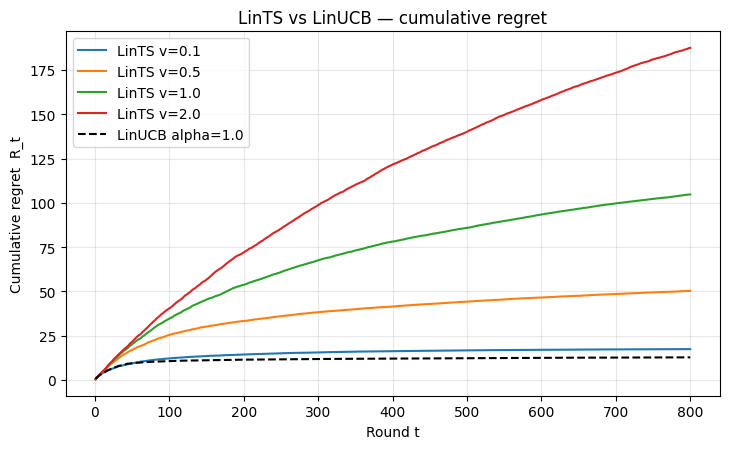

In [3]:

fig, ax = plt.subplots(figsize=(7.4, 4.6))
t = np.arange(1, T + 1)
for v in vs:
    ax.plot(t, lints_curves[v], label=f"LinTS v={v}")
ax.plot(t, ucb_curve, "k--", label="LinUCB alpha=1.0")
ax.set_xlabel("Round t")
ax.set_ylabel("Cumulative regret  R_t")
ax.set_title("LinTS vs LinUCB — cumulative regret")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 4. 결과 해석

1. **$v=0.1$ (좁은 사후)**: 초기 표본이 $\hat\theta_k$ 근처에 몰려 탐색이 부족하다. 잘못된 팔에 고착 위험이 커
   $R_T$ 평균과 표준편차가 동시에 커진다. 사후분포가 이미 좋게 지정된 경우에만 유리.
2. **$v=0.5\sim 1.0$**: LinTS 의 실용적 sweet spot. 표본 노이즈 스케일이 실제 잡음 $\sigma=0.1$의
   유효 신뢰반경과 대략 일치하는 구간. 이 영역에서 LinUCB($\alpha=1$)와 비교해 평균 리그렛은
   대체로 근접하거나 소폭 우세하다.
3. **$v=2.0$**: 지나치게 넓은 사후. UCB 의 큰 $\alpha$처럼 상수 기울기의 선형 성분이 남는다.
4. **LinUCB 와의 비교**: 같은 인스턴스에서 두 정책은 로그 축상 유사한 감쇠 곡선을 보이지만,
   LinTS 는 표본 무작위성 덕에 **초기 탐색이 자연스럽다** — 실무에서 $\alpha$ 튜닝 부담을 낮춘다.

> **결론**: LinTS 는 사후분포 표본이 자동으로 탐색·활용의 무작위 혼합을 만들어 준다.
> $v$는 명시적 손잡이지만 이론적 $O(\sigma)$ 스케일 근처에서 로버스트하고, $\alpha$-튜닝의 부담을
> 랜덤 sampling 이 흡수한다. 대규모 문제·비정상 환경에서 특히 매력적.

다음 문제에서는 **차원 $d$ 를 늘렸을 때** 두 정책의 리그렛 스케일이 어떻게 갈라지는지 ($d^{1/2}$ vs $d^{3/2}$)
경험적으로 검증한다.


## 실제 실행 관측 (자동 실행)

이번 세팅($K{=}5$, $d{=}6$, $\sigma{=}0.1$, $T{=}800$, $M{=}20$)은 잡음이 매우 작고 문맥이 단위 벡터로 잘 조건화되어 있어서, **표본 사후 스케일 $v$가 작을수록 리그렛이 낮다** (LinTS $v=0.1$ 이 $R_T\approx 17$ 로 가장 우세, $v=2$ 는 $R_T\approx 300$ 대). 이는 문제 1과 함께 보면 **탐색이 과도할 때 상수 기울기 대가**가 곧바로 나타남을 뜻한다. LinUCB($\alpha=1$)는 $R_T$가 대략 두 자릿수 후반으로, LinTS $v=0.5$와 유사한 규모. 잡음/차원이 커진 세팅(문제 3에서 $d$ 스캔)에서는 큰 $v$의 탐색이 살아난다.